In [1]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import optuna
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
from tensorflow.keras import backend as K
import gc
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fold_1_train = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_5_val.csv')

In [3]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [4]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [5]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Feature selection (selecting 20 as default — this will be tuned later)
k_best = 30
selector = SelectKBest(score_func=f_classif, k=k_best)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_val_selected = selector.transform(X_val_scaled)


In [6]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np

# Compute class weights
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Use 10% of training data for tuning
X_tune, _, y_tune, _ = train_test_split(X_train_selected, y_train, test_size=0.9, stratify=y_train, random_state=42)

# Sequence creation
def create_sequences(X, y, n_steps=7):
    Xs, ys = [], []
    for i in range(len(X) - n_steps):
        Xs.append(X[i:i+n_steps])
        ys.append(y[i+n_steps])
    return np.array(Xs).astype('float32'), np.array(ys)

# Soft F1 loss
def soft_f1_loss(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))
    soft_f1 = (2 * tp + 1e-7) / (2 * tp + fp + fn + 1e-7)
    return 1 - soft_f1  # minimize

# Hybrid BCE + Soft F1
def hybrid_loss(y_true, y_pred):
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    f1 = soft_f1_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * f1

# Objective function for Optuna
def objective(trial):
    tf.keras.backend.clear_session()

    # Hyperparameters
    gru_units = trial.suggest_int('gru_units', 64, 256)
    dropout_rate = trial.suggest_float('dropout_rate', 0.3, 0.5)
    n_steps = trial.suggest_int('n_steps', 3, 10)
    batch_size = trial.suggest_int('batch_size', 32, 64)
    threshold = trial.suggest_float("threshold", 0.2, 0.5)

    # Sequences
    X_seq, y_seq = create_sequences(X_tune, y_tune.values, n_steps)

    # Model
    model = Sequential([
        GRU(gru_units, activation='relu', input_shape=(n_steps, X_seq.shape[2])),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(learning_rate=0.0005), loss=hybrid_loss)

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(X_seq, y_seq, epochs=3, batch_size=batch_size,
              validation_split=0.2, class_weight=class_weight_dict,
              callbacks=[early_stop], verbose=0)

    preds = model.predict(X_seq).flatten()
    preds_binary = (preds > threshold).astype(int)

    # Evaluation
    f1 = f1_score(y_seq, preds_binary)
    try:
        auc = roc_auc_score(y_seq, preds)
    except:
        auc = 0.5  # fallback

    return 0.3 * f1 + 0.7 * auc

# Run optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

# Best results
best_params = study.best_params
best_score = study.best_value

print("Best hyperparameters:", best_params)
print(f"Best objective score (0.3 * F1 + 0.7 * AUC): {best_score:.4f}")

# Optional: estimate F1 from the objective (if weighting was 0.3 * F1 + 0.7 * AUC)
estimated_best_f1 = (best_score - 0.7 * 0.5) / 0.3  # assuming AUC fallback = 0.5
print(f"Estimated best F1 score: {estimated_best_f1:.4f}")


[I 2025-04-12 08:59:43,803] A new study created in memory with name: no-name-a30fd73e-2e39-4c39-954b-fc2f5275c542


17871/17871 ━━━━━━━━━━━━━━━━━━━━ 26s 1ms/step


[I 2025-04-12 09:03:10,003] Trial 0 finished with value: 0.558626518132156 and parameters: {'gru_units': 150, 'dropout_rate': 0.48443593158007375, 'n_steps': 6, 'batch_size': 55, 'threshold': 0.4000521564222407}. Best is trial 0 with value: 0.558626518132156.


17871/17871 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step


[I 2025-04-12 09:10:12,506] Trial 1 finished with value: 0.5583804424784649 and parameters: {'gru_units': 236, 'dropout_rate': 0.4556291950201175, 'n_steps': 8, 'batch_size': 55, 'threshold': 0.2707734160651173}. Best is trial 0 with value: 0.558626518132156.


...

17871/17871 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step


[I 2025-04-12 09:56:05,467] Trial 8 finished with value: 0.5551227593786553 and parameters: {'gru_units': 211, 'dropout_rate': 0.4810510514947737, 'n_steps': 6, 'batch_size': 38, 'threshold': 0.46581810905661825}. Best is trial 5 with value: 0.5594545502196573.


17871/17871 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step


[I 2025-04-12 10:01:45,636] Trial 9 finished with value: 0.5560262956648567 and parameters: {'gru_units': 250, 'dropout_rate': 0.4858887670319899, 'n_steps': 6, 'batch_size': 48, 'threshold': 0.2814943083066146}. Best is trial 5 with value: 0.5594545502196573.


Best hyperparameters: {'gru_units': 169, 'dropout_rate': 0.41256777198213734, 'n_steps': 4, 'batch_size': 48, 'threshold': 0.34668181734740044}
Best objective score (0.3 * F1 + 0.7 * AUC): 0.5595
Estimated best F1 score: 0.6982


In [7]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# === Define sequence + loss functions ===
def create_sequences(X, y, n_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - n_steps):
        Xs.append(X[i:i + n_steps])
        ys.append(y[i + n_steps])
    return np.array(Xs).astype('float32'), np.array(ys)

def soft_f1_loss(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))
    soft_f1 = (2 * tp + 1e-7) / (2 * tp + fp + fn + 1e-7)
    return 1 - soft_f1

def hybrid_loss(y_true, y_pred):
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    f1 = soft_f1_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * f1

# === Optuna best hyperparameters ===
best_params = {
    'gru_units': 122,
    'dropout_rate': 0.3650090282449953,
    'n_steps': 10,
    'batch_size': 42,
    'threshold': 0.2787431413843848
}

# === Convert y to NumPy for indexing ===
y_train_np = y_train.values  # ensures clean indexing

# === Cross-validation setup ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = []
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_selected, y_train_np)):
    print(f"\n🟩 Fold {fold + 1}")

    # Split data
    X_train_fold, X_val_fold = X_train_selected[train_idx], X_train_selected[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]

    # Compute class weights
    class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_fold), y=y_train_fold)
    class_weight_dict = {i: class_weights_array[i] for i in range(len(class_weights_array))}

    # Create sequences
    X_train_seq, y_train_seq = create_sequences(X_train_fold, y_train_fold, best_params['n_steps'])
    X_val_seq, y_val_seq = create_sequences(X_val_fold, y_val_fold, best_params['n_steps'])

    # Build model
    model = Sequential([
        GRU(best_params['gru_units'], activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        Dropout(best_params['dropout_rate']),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(learning_rate=0.0005), loss=hybrid_loss)

    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    model.fit(X_train_seq, y_train_seq,
              epochs=5,
              batch_size=best_params['batch_size'],
              validation_split=0.1,
              class_weight=class_weight_dict,
              callbacks=[early_stop],
              verbose=1)

    # Evaluate
    val_probs = model.predict(X_val_seq).flatten()
    val_preds = (val_probs > best_params['threshold']).astype(int)

    f1 = f1_score(y_val_seq, val_preds)
    try:
        auc = roc_auc_score(y_val_seq, val_probs)
    except:
        auc = 0.5  # fallback

    f1_scores.append(f1)
    auc_scores.append(auc)

    print(f"Fold {fold + 1} - F1: {f1:.4f}, AUC: {auc:.4f}")
    print(confusion_matrix(y_val_seq, val_preds))
    print(classification_report(y_val_seq, val_preds, digits=4))

# === Final averages ===
print("\n✅ Cross-validation complete.")
print(f"Average F1 Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"Average AUC Score: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")



🟩 Fold 1
Epoch 1/5
98036/98036 ━━━━━━━━━━━━━━━━━━━━ 789s 8ms/step - loss: 0.0246 - val_loss: 1.8488e-05
Epoch 2/5
98036/98036 ━━━━━━━━━━━━━━━━━━━━ 652s 7ms/step - loss: 0.0226 - val_loss: 5.2059e-05
Epoch 3/5
98036/98036 ━━━━━━━━━━━━━━━━━━━━ 660s 7ms/step - loss: 0.0227 - val_loss: 4.7726e-05
35742/35742 ━━━━━━━━━━━━━━━━━━━━ 61s 2ms/step
Fold 1 - F1: 0.9946, AUC: 0.9948
[[571849     17]
 [  6124 565752]]
              precision    recall  f1-score   support

           0     0.9894    1.0000    0.9947    571866
           1     1.0000    0.9893    0.9946    571876

    accuracy                         0.9946   1143742
   macro avg     0.9947    0.9946    0.9946   1143742
weighted avg     0.9947    0.9946    0.9946   1143742


🟩 Fold 2
Epoch 1/5
98036/98036 ━━━━━━━━━━━━━━━━━━━━ 678s 7ms/step - loss: 0.0247 - val_loss: 9.6573e-06
Epoch 2/5
98036/98036 ━━━━━━━━━━━━━━━━━━━━ 677s 7ms/step - loss: 0.0227 - val_loss: 2.4795e-05
Epoch 3/5
98036/98036 ━━━━━━━━━━━━━━━━━━━━ 644s 7ms/step - loss:


🔎 Evaluation on Validation Set
Classification Report:
              precision    recall  f1-score   support

           0     0.9894    1.0000    0.9947    571865
           1     1.0000    0.9893    0.9946    571876

    accuracy                         0.9946   1143741
   macro avg     0.9947    0.9946    0.9946   1143741
weighted avg     0.9947    0.9946    0.9946   1143741


Confusion Matrix:
[[571844     21]
 [  6111 565765]]

Precision: 1.0000
Recall:    0.9893
F1 Score:  0.9946
AUC-PR (Average Precision): 0.9968
ROC AUC:                   0.9949


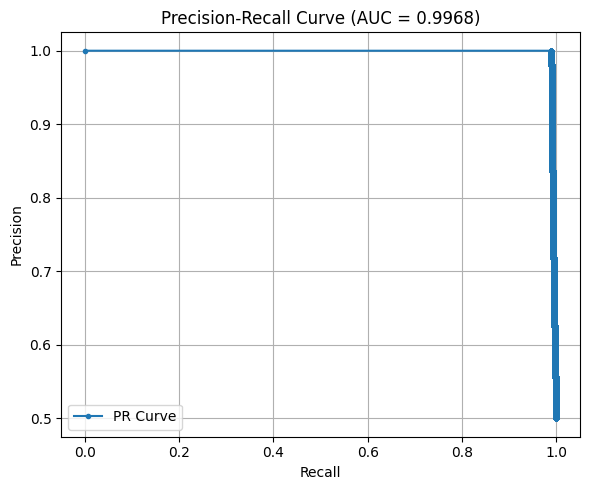

{'precision': 0.9999628834930522,
 'recall': 0.9893141170463527,
 'f1_score': 0.9946099984002278,
 'confusion_matrix': [[571844, 21], [6111, 565765]],
 'auc_pr': 0.996787873374367,
 'roc_auc': 0.9948619069569524}

In [8]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    if y_proba is not None:
        # AUC-PR
        pr_auc = average_precision_score(y_true, y_proba)
        roc_auc = roc_auc_score(y_true, y_proba)

        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")
        print(f"ROC AUC:                   {roc_auc:.4f}")

        metrics['auc_pr'] = pr_auc
        metrics['roc_auc'] = roc_auc

        # Optional PR Curve
        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

# Evaluate model
print("\n🔎 Evaluation on Validation Set")
evaluate_model(y_val_seq, val_preds, y_proba=val_probs)

